# synthetic example

Used to create figure 1 in the paper.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np

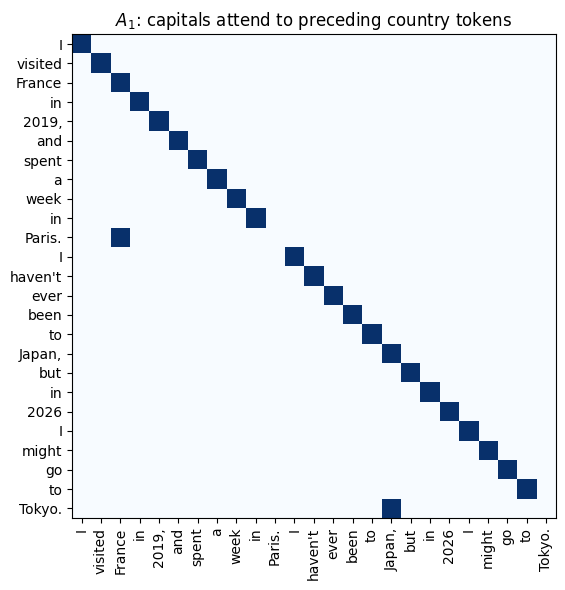

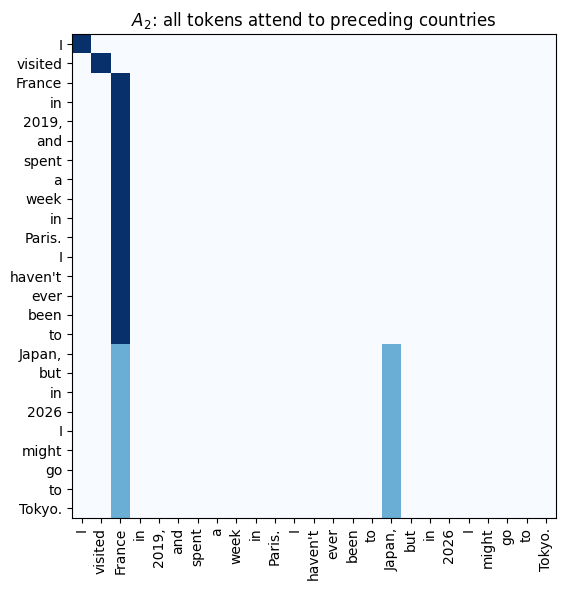

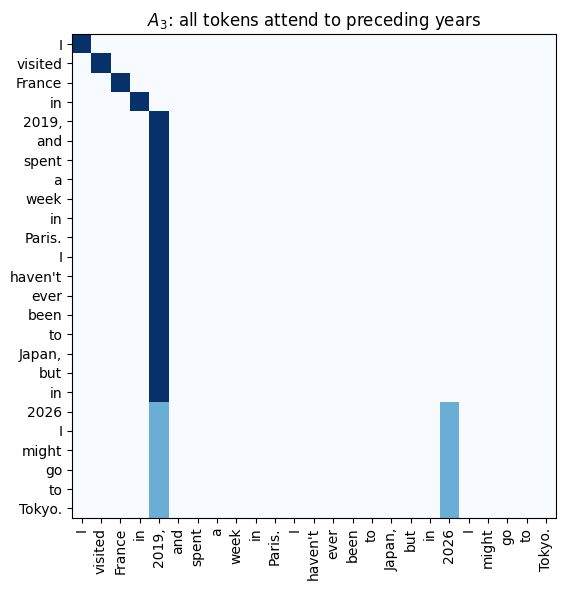

In [2]:
capitals_to_country: dict[str, str] = {
	"paris": "france",
	"tokyo": "japan",
	"berlin": "germany",
	"madrid": "spain",
	"rome": "italy",
	"london": "united",
	"ottawa": "canada",
	"beijing": "china",
	"washington": "states",
	"moscow": "russia",
}
countries: set[str] = set(capitals_to_country.values())


def clean_token(token: str) -> str:
	"""lowercase, drop punctuation except digits/letters."""
	return re.sub(r"[^\w\d]", "", token.lower())


def tokenize(text: str) -> list[str]:
	"""Split by spaces, then split on apostrophes and keep the first part."""
	return text.split()


# Softmax with -inf masking
def rowwise_softmax(logits: np.ndarray) -> np.ndarray:
	out = np.empty_like(logits)
	for i, row in enumerate(logits):
		# Handle rows that are entirely -inf (will happen after masking).
		if np.isneginf(row).all():
			out[i] = np.eye(1, logits.shape[1], i, dtype=float)[0]  # self-attention
			continue
		valid = row[~np.isneginf(row)]
		m = valid.max()
		exp_row = np.exp(row - m, where=~np.isneginf(row), dtype=float)
		exp_row[np.isneginf(row)] = 0.0
		out[i] = exp_row / exp_row.sum()
	return out


def make_attention(tokens: list[str]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
	n = len(tokens)
	# initialise logits to -inf everywhere
	A1 = np.full((n, n), -np.inf)
	A2 = np.full((n, n), -np.inf)
	A3 = np.full((n, n), -np.inf)

	clean_tokens = [clean_token(t) for t in tokens]
	country_idxs = [i for i, ct in enumerate(clean_tokens) if ct in countries]
	year_idxs = [i for i, ct in enumerate(clean_tokens) if re.fullmatch(r"\d{4}", ct)]

	for i, ct in enumerate(clean_tokens):
		# ----- A1: capitals -> their country (earlier only) -------------------
		if ct in capitals_to_country:
			target_country = capitals_to_country[ct]
			idxs = [
				j
				for j, cct in enumerate(clean_tokens)
				if cct == target_country and j <= i
			]  # causal
			if idxs:
				for j in idxs:
					A1[i, j] = 0.0  # equal logits, will softmax later
		# fallback self
		if np.isneginf(A1[i]).all():
			A1[i, i] = 0.0

		# ----- A2: any -> country tokens (earlier only) -----------------------
		earlier_countries = [j for j in country_idxs if j <= i]
		if earlier_countries:
			for j in earlier_countries:
				A2[i, j] = 0.0
		else:
			A2[i, i] = 0.0

		# ----- A3: any -> year tokens (earlier only) --------------------------
		earlier_years = [j for j in year_idxs if j <= i]
		if earlier_years:
			for j in earlier_years:
				A3[i, j] = 0.0
		else:
			A3[i, i] = 0.0

	# Causal mask: upper triangular (j>i) already -inf by construction.

	# Softmax rows
	A1 = rowwise_softmax(A1)
	A2 = rowwise_softmax(A2)
	A3 = rowwise_softmax(A3)
	return A1, A2, A3


def plot_matrix(mat: np.ndarray, tokens: list[str], title: str) -> None:
	plt.figure(figsize=(8, 6))
	plt.imshow(mat, cmap="Blues", vmin=0, vmax=1)
	plt.xticks(range(len(tokens)), tokens, rotation=90)
	plt.yticks(range(len(tokens)), tokens)
	plt.title(title)
	plt.tight_layout()
	# plt.show()


# ----- Example ----------------------------------------------------------------
text = (
	"I visited France in 2019, and spent a week in Paris. "
	"I haven't ever been to Japan, but in 2026 I might go to Tokyo."
)

tokens = tokenize(text)
A1, A2, A3 = make_attention(tokens)

plot_matrix(A1, tokens, "$A_1$: capitals attend to preceding country tokens")
plt.savefig("figures/fake-attn/A1.pdf", bbox_inches="tight")
plot_matrix(A2, tokens, "$A_2$: all tokens attend to preceding countries")
plt.savefig("figures/fake-attn/A2.pdf", bbox_inches="tight")
plot_matrix(A3, tokens, "$A_3$: all tokens attend to preceding years")
plt.savefig("figures/fake-attn/A3.pdf", bbox_inches="tight")